In [1]:
from pathlib import Path
import sys

dirpath_root = Path().resolve().parents[2]
sys.path.append(str(dirpath_root))
print(dirpath_root)

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

/ddn/niknovikov19/repo/A1_OUinp


In [2]:
def fit_sinusoid_fixed_freq(rr, osc_f, osc_t0):
    tt = np.asarray(rr.time.values, dtype=float)
    yy = np.asarray(rr.values, dtype=float)
    mask = tt >= osc_t0
    tt = tt[mask]
    yy = yy[mask]
    phase = 2 * np.pi * float(osc_f) * (tt - float(osc_t0))
    X = np.column_stack([
        np.sin(phase),
        np.cos(phase),
        np.ones_like(phase),
    ])
    coef, _, _, _ = np.linalg.lstsq(X, yy, rcond=None)
    a_sin, a_cos, offset = coef
    yfit = a_sin * np.sin(phase) + a_cos * np.cos(phase) + offset
    z_out = a_cos - 1j * a_sin
    return tt, yfit, z_out, float(offset)


def print_transfer_coeffs(rates_xr, pops_vis):
    osc_t0 = float(rates_xr.attrs['OSC_T0'])
    osc_f = float(rates_xr.attrs['OSC_F'])
    osc_amp = float(rates_xr.attrs['OSC_AMP'])
    if osc_amp == 0:
        raise ValueError('OSC_AMP is zero, transfer coefficient is undefined')

    z_in = -1j * osc_amp
    print(f'OSC_T0 = {osc_t0}')
    print(f'OSC_F = {osc_f}')
    print(f'OSC_AMP = {osc_amp}')
    print('Transfer coefficients:')
    fit_data = {}
    for pop in pops_vis:
        rr = rates_xr.sel(pop=pop)
        tt_fit, yfit, z_out, offset = fit_sinusoid_fixed_freq(rr, osc_f, osc_t0)
        H = z_out / z_in
        fit_data[pop] = (tt_fit, yfit)
        print(
            f'  {pop}: H = {H.real:+.6g}{H.imag:+.6g}j '
            f'|H| = {abs(H):.6g} phase = {np.angle(H):.6g} rad '
            f'offset = {offset:.6g}'
        )
    return fit_data

Loading: /ddn/niknovikov19/repo/A1_OUinp/exp_results/batch_rxbkg_unconn_state1_mech1/net_inpsur_hr_osc_var_seed_f_amp/exp_hr_osc_L2_nseed_1_nf_1_namp_10_t_5.0_20.0_osc_t0_5000_ictrl_wmult_0.25_ee_0.5/rvec_xr/rvec_00008_seed_1000_f_5_amp_0.143374.nc


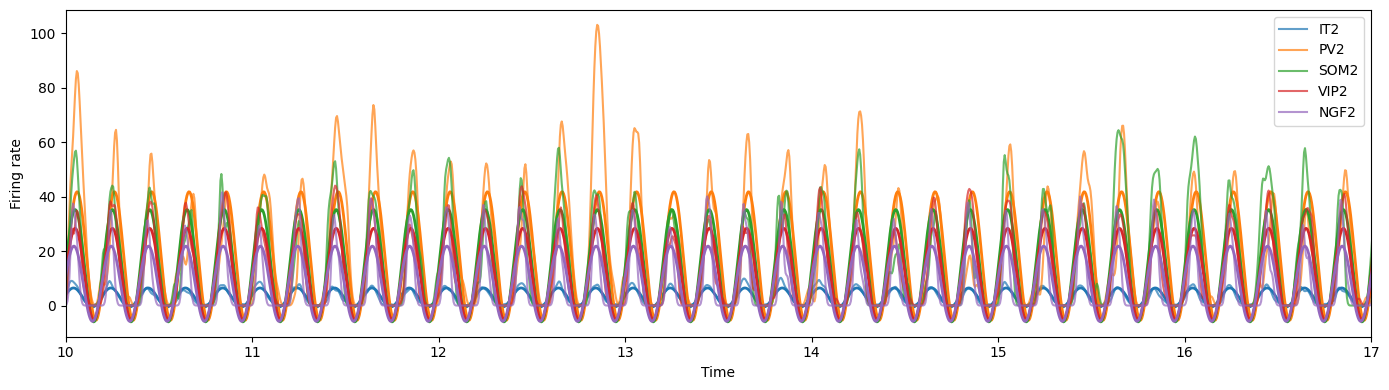

In [13]:
EXP_NAME_BASE = 'batch_rxbkg_unconn_state1_mech1'
EXP_NAME = 'net_inpsur_hr_osc_var_seed_f_amp'

EXP_NAME_SUB = 'exp_hr_osc_L2_nseed_1_nf_1_namp_10_t_5.0_20.0_osc_t0_5000_ictrl_wmult_0.25_ee_0.5'
JOB_NAME = 'rvec_00008_seed_1000_f_5_amp_0.143374'

fpath_in = (dirpath_root / 'exp_results' / EXP_NAME_BASE / EXP_NAME / 
            EXP_NAME_SUB / 'rvec_xr' / f'{JOB_NAME}.nc')
print(f'Loading: {fpath_in}')

rates_xr = xr.load_dataarray(fpath_in)
pops_vis = [
    pop for pop in rates_xr.pop.values
    if 'frz' not in pop
    #and pop in ['IT2', 'PV2']
]
#fit_data = print_transfer_coeffs(rates_xr, pops_vis)

osc_t0 = float(rates_xr.attrs['OSC_T0']) / 1000
osc_f = float(rates_xr.attrs['OSC_F'])
osc_amp = float(rates_xr.attrs['OSC_AMP'])

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.figure(figsize=(14, 4))
for n, pop in enumerate(pops_vis):
    rr = rates_xr.sel(pop=pop)
    col = colors[n % len(colors)]
    plt.plot(rr.time.values, rr.values, label=pop, color=col, alpha=0.7)

    #tt_fit, yfit = fit_data[pop]
    tt_fit, yfit, z_out, offset = fit_sinusoid_fixed_freq(rr, osc_f, osc_t0)
    plt.plot(tt_fit, yfit, '-', color=col, alpha=1, linewidth=2)

plt.xlabel('Time')
plt.ylabel('Firing rate')
plt.xlim(10, 17)
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [9]:
osc_t0

5000.0